!pip install = Pip is a tool for installing python packages ,using an exclamation mark before the pip install will pass the command to the shell and not to the Python interpreter

pandas = A fast and efficient DataFrame object for data manipulation with integrated indexing

geopandas = It extends the popular pandas library to handle spatial (geographic) data - such as maps, shapes and coordinates. It can read shapefiles, GeoJSON, or other GIS data formats.

shapely = It is a geometry library for Python. It helps create and manipulate geometric shapes like points, lines, and polygons mathematically.

scikit-learn = One of the most popular machine learning libraries in Python. It is often used with GeoPandas when we want to apply machine learning to spatial data.

matplotlib = A plotting and visualization library for Python. It helps create all kinds of charts: line plots, bar charts, histograms, maps, etc.

contextily = A Python library used to add background map tiles (like basemaps from OpenStreetMap or Stamen) to GeoPandas plots. It helps to visualize geographic data on real-world maps.

In [1]:
!pip install geopandas shapely scikit-learn matplotlib contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 118.6 MB/s eta 0:00:00


This line imports the files module from the Google Colab package. It is a special module that helps to move files between local computer and the Colab environment

In [3]:
from google.colab import files

This line imports the GeoPandas library and gives it a short alias gpd so that we can type gpd instead of geopandas every time.

In [4]:
import pandas as pd
import geopandas as gpd

gpd.read_file() = is a GeoPandas function used to read geospatial data files (like shapefiles, GeoJSON, etc.)

The file I have used is a Shapefile (.shp) — a common format for storing geographic boundaries (like countries, states, cities, etc.).

.head() = is a Pandas/GeoPandas method that shows the first 5 rows of the DataFrame.It is used to quickly inspect the data and see what columns and values it contains.

In [5]:
world_boundaries = gpd.read_file("/content/sample_data/world-administrative-boundaries-countries.shp")
world_boundaries.head()

,iso3_code,iso2_code,preferred_t,english_sho,french_shor,spanish_sho,russian_sho,chinese_sho,arabic_shor,region_code,region_name,sub_region_,sub_region_,geometry
0,EST,EE,Estonia,Estonia,Estonie (l') [fém.],Estonia,Эстония,爱沙尼亚,إستونيا,150,Europe,Northern Europe,Northern Europe,"MULTIPOLYGON (((22.98485 58.59944, 23.09083 58..."
1,IRQ,IQ,Iraq,Iraq,Iraq (l') [masc.],Iraq (el),Ирак,伊拉克,العراق,142,Asia,Western Asia,Western Asia,"POLYGON ((44.78734 37.14971, 44.76617 37.11228..."
2,AFG,AF,Afghanistan,Afghanistan,Afghanistan (l') [masc.],Afganistán (el),Афганистан,阿富汗,أفغانستان,142,Asia,Southern Asia,Southern Asia,"POLYGON ((74.91574 37.23733, 74.80873 37.22423..."
3,ABW,AW,Aruba,Aruba,None,None,None,None,None,19,Americas,Latin America and the Caribbean,Latin America and the Caribbean,"POLYGON ((-69.87486 12.41528, -69.88224 12.411..."
4,ERI,ER,Eritrea,Eritrea,Érythrée (l') [fém.],Eritrea,Эритрея,厄立特里亚,إريتريا,2,Africa,Sub-Saharan Africa,Sub-Saharan Africa,"MULTIPOLYGON (((40.13583 15.7525, 40.12861 15...."


In [6]:
CSV = gpd.read_file("/content/sample_data/world_population.csv")
CSV.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.01,0


'import contextily as ctx' = Importing contextily and an alias ctx which makes it shorter to call later.

'import matplotlib.pyplot as plt' = Imports Matplotlib’s Pyplot module, a popular library for plotting graphs and charts in Python. The alias plt is a common convention used to make commands shorter

'from sklearn.preprocessing import StandardScaler' = Imports StandardScaler from the Scikit-learn (sklearn) library. It is used to standardize (normalize) numerical data by removing the mean and scaling to unit variance. Many machine learning algorithms (like K-Means) perform better when features are on the same scale.

'from sklearn.cluster import KMeans' = Imports the K-Means clustering algorithm from Scikit-learn.
K-Means is an unsupervised learning algorithm used to group data points into clusters based on their similarity.

'from matplotlib.cm import ScalarMappable' = Imports ScalarMappable from Matplotlib’s colormap (cm) module. Used to map numerical values to colors — for example, when coloring clusters or regions based on their values.

In [7]:
import contextily as ctx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from matplotlib.cm import ScalarMappable

.loc[:, ...] selects all rows (:) and specific columns.
~world_boundaries.columns.duplicated() creates a boolean mask that removes duplicate column names (the ~ means “not”).

Purpose:
Sometimes shapefiles or merges produce duplicate columns — this line ensures only unique columns remain in world_pop.

.merge() joins two datasets — here, world_pop (geospatial data) and CSV (population data).

left_on="iso3_code" = uses the country code column from the shapefile.

right_on="CCA3" = uses the country code column from the CSV file.

how="left" = keeps all countries from the left dataset (world_pop), even if some don’t have population data.

.dropna() removes rows with any missing values

X_index = X.index = Saves the index (row positions) of the filtered data

StandardScaler() standardizes data so each feature has mean = 0 and standard deviation = 1

.fit_transform() both learns the scaling parameters (fit) and applies the transformation (transform)

random_state=42 ensures reproducibility (same results every time).

.fit_predict() fits the model to the scaled data and assigns each row (country) to a cluster (returns an array of cluster)

merged_world_pop['cluster'] = None = Creates a new column 'cluster' in the GeoDataFrame. Initializes all rows with None (empty values).

merged_world_pop.loc[X_index, 'cluster'] = clusters = Adds the K-Means cluster result to the main GeoDataFrame, linking geographic shapes with clustering results.

In [8]:
world_pop = world_boundaries.loc[:, ~world_boundaries.columns.duplicated()]
merged_world_pop = world_pop.merge(CSV, left_on="iso3_code", right_on="CCA3", how="left")

X = merged_world_pop[['1990 Population','1980 Population', '1970 Population', 'Growth Rate']].dropna()
X_index = X.index

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

merged_world_pop['cluster'] = None
merged_world_pop.loc[X_index, 'cluster'] = clusters

.to_crs() means “convert to a new coordinate reference system (CRS)”.

epsg=3857 refers to the Web Mercator projection, the standard coordinate system used by most web maps

In [9]:
# Reproject to Web Mercator (EPSG:3857) for compatibility with contextily
merged_world_pop_web = merged_world_pop.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(16, 10)) = This line sets up a large plotting area for your map or chart, giving you a figure (fig) to hold everything and axes (ax) to draw on.

'YlOrRd' is a predefined colormap (“Yellow → Orange → Red”), good for showing increasing values.
kmeans.n_clusters → the number of discrete colors we want (one for each cluster).

.min() finds the minimum value in the cluster column of your GeoDataFrame.
vmin will typically be 0 if clusters are numbered

.max() finds the maximum value in the cluster column.
vmax will be the highest cluster number

/tmp/ipython-input-800953842.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd', kmeans.n_clusters)


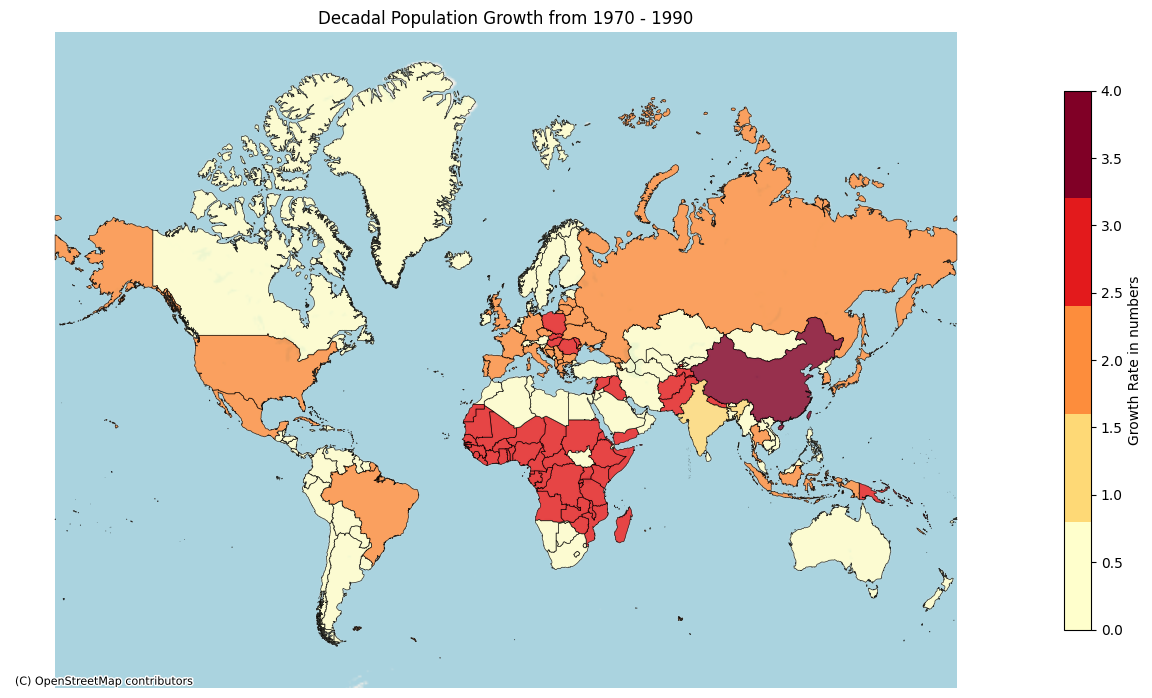

In [14]:
fig, ax = plt.subplots(figsize=(16, 10))

# Define colormap and normalization for continuous-like colorbar
cmap = plt.cm.get_cmap('YlOrRd', kmeans.n_clusters)
vmin = merged_world_pop_web['cluster'].min()
vmax = merged_world_pop_web['cluster'].max()

merged_world_pop_web.plot(
    column="cluster",
    cmap=cmap,
    linewidth=0.5,
    edgecolor="black",
    ax=ax,
    vmin=vmin,
    vmax=vmax,
    alpha=0.8
)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = [] # workaround for a bug
cbar = fig.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label("Growth Rate in numbers")

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
plt.title("Decadal Population Growth from 1970 - 1990")
plt.axis('off')
plt.show()

Interpretation = Dark Red (4.0 and above): These areas saw the highest population growth (above 4.0 in growth rate), mostly concentrated in parts of Some parts of Africa, India, and China. These regions experienced rapid population growth during this period.

Red and Orange (2.0 to 4.0): This shows countries with moderate to high population growth, which includes many countries in the developing world, especially in Africa, South Asia, and Latin America.

Yellow and Light Orange (0.0 to 2.0): Countries with relatively slower growth or more stable population trends, including parts of Europe and some parts of Asia.

White: Countries that are shaded white appear to have no data available for the period 1970-1990. This can occur for several reasons:

1.) The country may have had limited or incomplete data collection for that period.

2.) Some countries may have been too small, newly formed, or going through major political changes, affecting the availability of reliable demographic data.

3.) This could also reflect cases where certain regions did not have sufficient census or demographic surveys in this period.

